# Week 8: Support Vector Machines

**Goal:** Apply SVM with multiple kernels to SER.  Implement a simplified linear SVM in MiniLearn; use sklearn for kernel variants.

**Deliverable:** `minilearn/classifiers.py` (LinearSVM complete) + this notebook.

---
## Checklist
- [ ] `LinearSVM` in MiniLearn — subgradient descent on hinge loss
- [ ] sklearn SVC with linear, RBF, and polynomial kernels
- [ ] Hyperparameter tuning: C, gamma
- [ ] ROC/AUC curves (One-vs-Rest)
- [ ] MiniLearn LinearSVM vs sklearn linear SVM comparison

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.classifiers import LinearSVM
from minilearn.metrics import accuracy, f1_score, confusion_matrix, roc_auc_score

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


def plot_confusion(cm, title, ax, labels):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)


# Load Week-5 preprocessed arrays
X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Classes : {np.unique(y_train)}')

X_train : (1956, 112)   X_test : (496, 112)
Classes : [1 2 3 4 5 6 7 8]


## 1. MiniLearn LinearSVM

=== MiniLearn LinearSVM (OVR) ===
Accuracy : 0.6069
Macro F1 : 0.5940


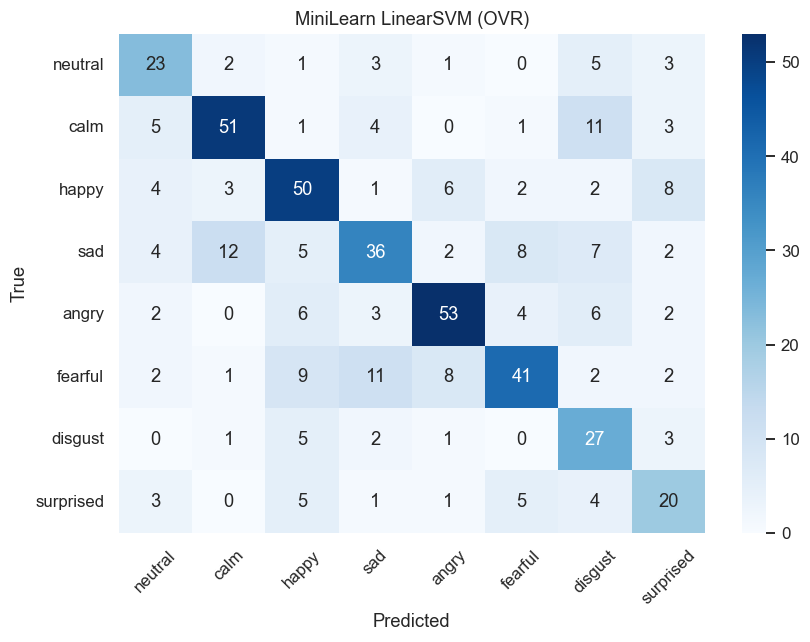

In [2]:
# LinearSVM is binary, so we wrap it with One-vs-Rest for 8-class SER.
class OVRLinearSVM:
    """One-vs-Rest wrapper around MiniLearn LinearSVM."""

    def __init__(self, C=1.0, lr=0.001, n_iter=1000):
        self.C = C; self.lr = lr; self.n_iter = n_iter
        self.classifiers_ = []; self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = []
        for c in self.classes_:
            y_bin = np.where(y == c, 1, 0)   # positive: class c, negative: rest
            clf = LinearSVM(C=self.C, lr=self.lr, n_iter=self.n_iter)
            clf.fit(X, y_bin)
            self.classifiers_.append(clf)
        return self

    def decision_scores(self, X):
        """Raw margin scores, shape (n_samples, n_classes)."""
        X = np.asarray(X, dtype=float)
        return np.column_stack([
            X @ clf.weights_ + clf.bias_ for clf in self.classifiers_
        ])

    def predict(self, X):
        return self.classes_[np.argmax(self.decision_scores(X), axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))


# ── Fit and evaluate ─────────────────────────────────────────────────────────
ovr_svm = OVRLinearSVM(C=1.0, lr=0.001, n_iter=500)
ovr_svm.fit(X_train, y_train)
y_pred_ml_svm = ovr_svm.predict(X_test)

print('=== MiniLearn LinearSVM (OVR) ===')
print(f'Accuracy : {accuracy(y_test, y_pred_ml_svm):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_ml_svm, average="macro"):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
plot_confusion(confusion_matrix(y_test, y_pred_ml_svm),
               'MiniLearn LinearSVM (OVR)', ax, emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_minilearn_svm.png'), bbox_inches='tight')
plt.show()

## 2. sklearn SVM — Multiple Kernels

Linear      acc=0.6431  f1=0.6329
RBF         acc=0.6734  f1=0.6644
Poly-2      acc=0.5605  f1=0.5280
Poly-3      acc=0.5403  f1=0.5001

        Accuracy  Macro-F1
Kernel                    
Linear    0.6431    0.6329
RBF       0.6734    0.6644
Poly-2    0.5605    0.5280
Poly-3    0.5403    0.5001


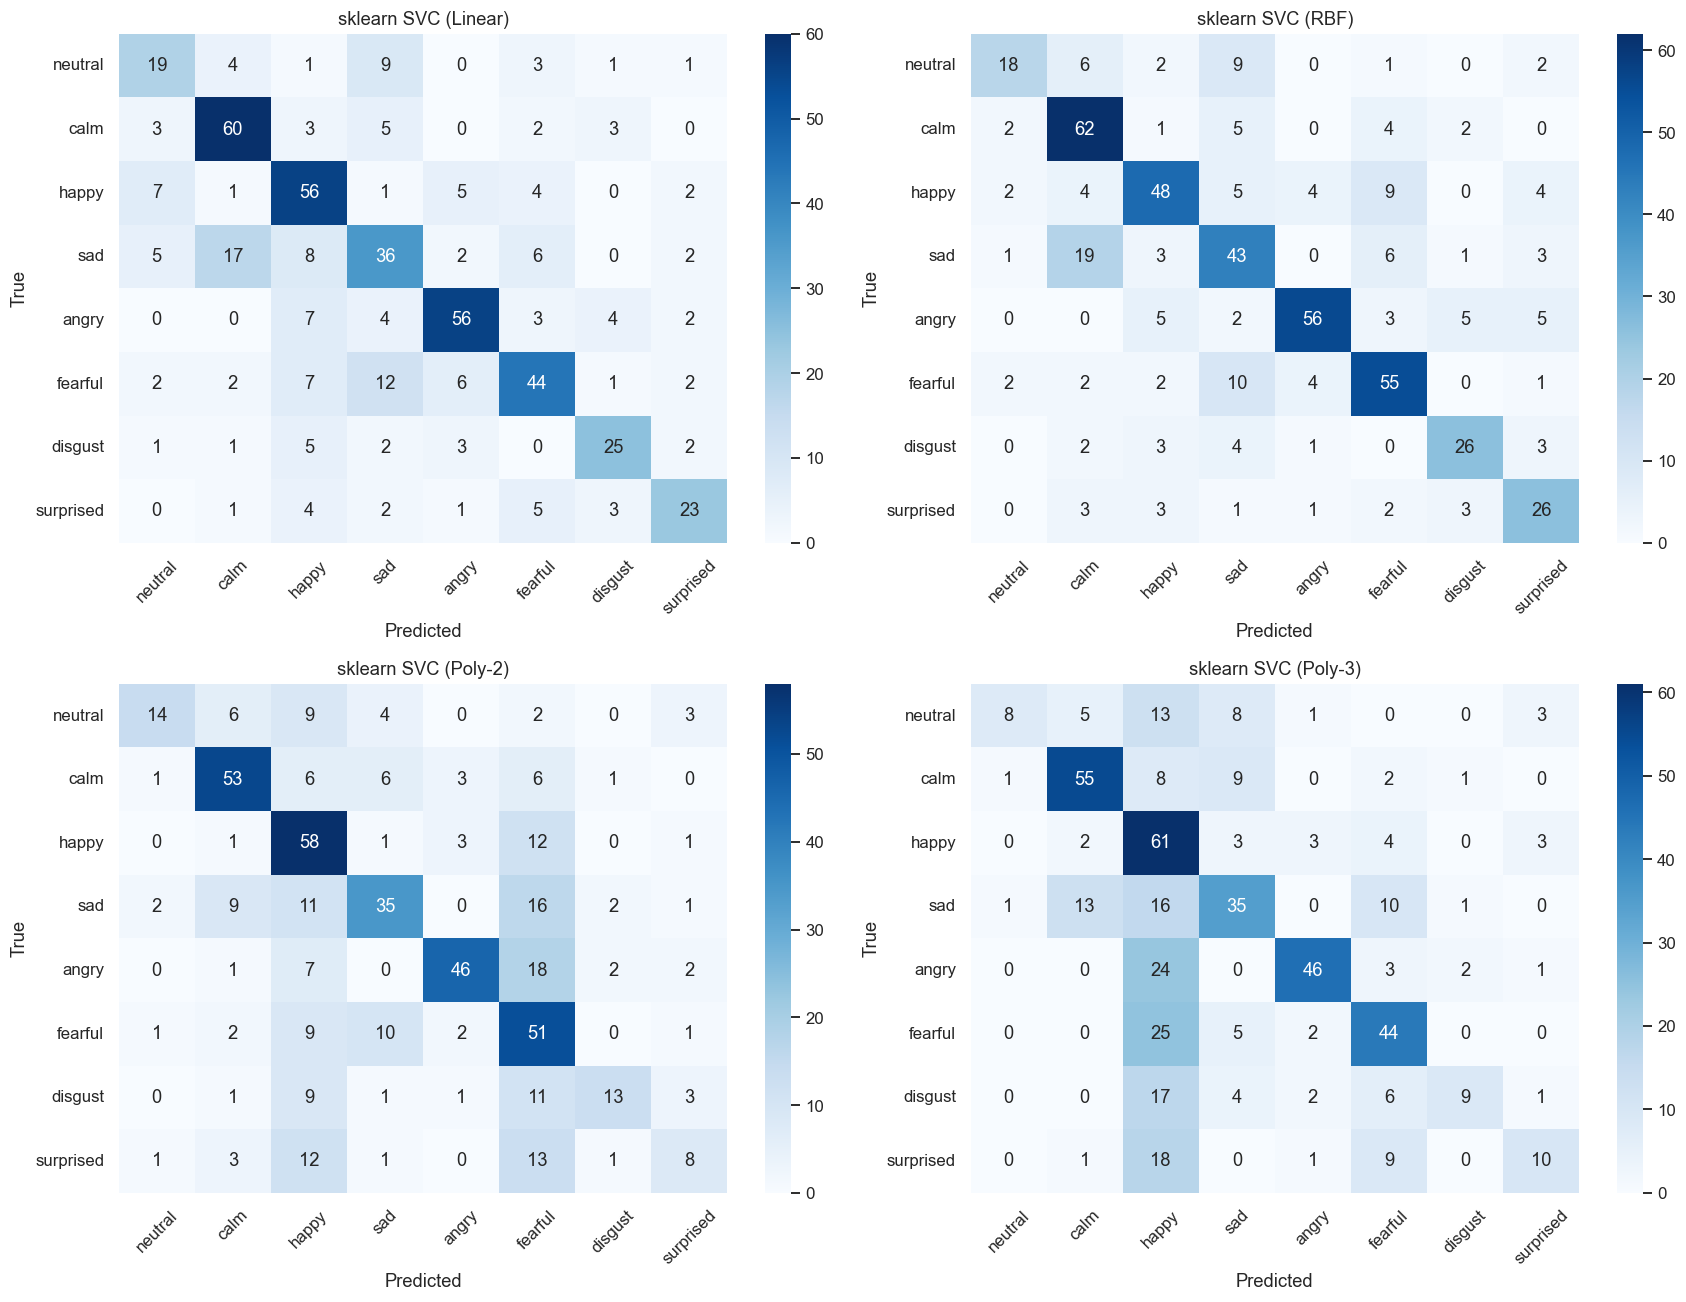

In [3]:
kernels = {
    'Linear':  SVC(kernel='linear',  C=1.0, decision_function_shape='ovr'),
    'RBF':     SVC(kernel='rbf',     C=1.0, gamma='scale', decision_function_shape='ovr'),
    'Poly-2':  SVC(kernel='poly',    C=1.0, degree=2, gamma='scale', decision_function_shape='ovr'),
    'Poly-3':  SVC(kernel='poly',    C=1.0, degree=3, gamma='scale', decision_function_shape='ovr'),
}

sk_preds = {}
rows = []

for name, clf in kernels.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    sk_preds[name] = y_pred
    rows.append({
        'Kernel':    name,
        'Accuracy':  round(accuracy(y_test, y_pred), 4),
        'Macro-F1':  round(f1_score(y_test, y_pred, average='macro'), 4),
    })
    print(f'{name:<10}  acc={rows[-1]["Accuracy"]:.4f}  f1={rows[-1]["Macro-F1"]:.4f}')

print()
print(pd.DataFrame(rows).set_index('Kernel').to_string())

# ── Confusion matrices for all four kernels ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (name, y_pred) in zip(axes.flatten(), sk_preds.items()):
    plot_confusion(confusion_matrix(y_test, y_pred),
                   f'sklearn SVC ({name})', ax, emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_sklearn_svm_kernels.png'), bbox_inches='tight')
plt.show()

## 3. Hyperparameter Tuning — RBF Kernel

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params  : {'C': 10, 'gamma': 'scale'}
Best CV acc  : 0.7014


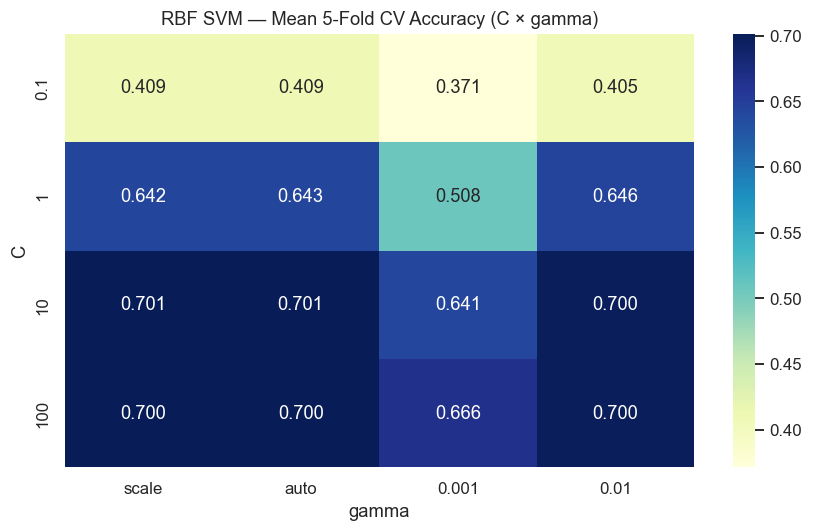


Test accuracy (best RBF) : 0.7560
Test macro F1 (best RBF) : 0.7465


In [4]:
C_values     = [0.1, 1, 10, 100]
gamma_values = ['scale', 'auto', 0.001, 0.01]

param_grid = {'C': C_values, 'gamma': gamma_values}
grid_search = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovr'),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best params  : {grid_search.best_params_}')
print(f'Best CV acc  : {grid_search.best_score_:.4f}')

# ── Reshape CV scores into a (C x gamma) grid ────────────────────────────────
results = grid_search.cv_results_
scores  = results['mean_test_score'].reshape(len(C_values), len(gamma_values))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    scores, annot=True, fmt='.3f', cmap='YlGnBu',
    xticklabels=[str(g) for g in gamma_values],
    yticklabels=[str(c) for c in C_values],
    ax=ax
)
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('RBF SVM — Mean 5-Fold CV Accuracy (C × gamma)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'svm_rbf_grid_search.png'), bbox_inches='tight')
plt.show()

# ── Evaluate best RBF model on test set ──────────────────────────────────────
best_rbf = grid_search.best_estimator_
y_pred_best_rbf = best_rbf.predict(X_test)
print(f'\nTest accuracy (best RBF) : {accuracy(y_test, y_pred_best_rbf):.4f}')
print(f'Test macro F1 (best RBF) : {f1_score(y_test, y_pred_best_rbf, average="macro"):.4f}')

## 4. ROC Curves

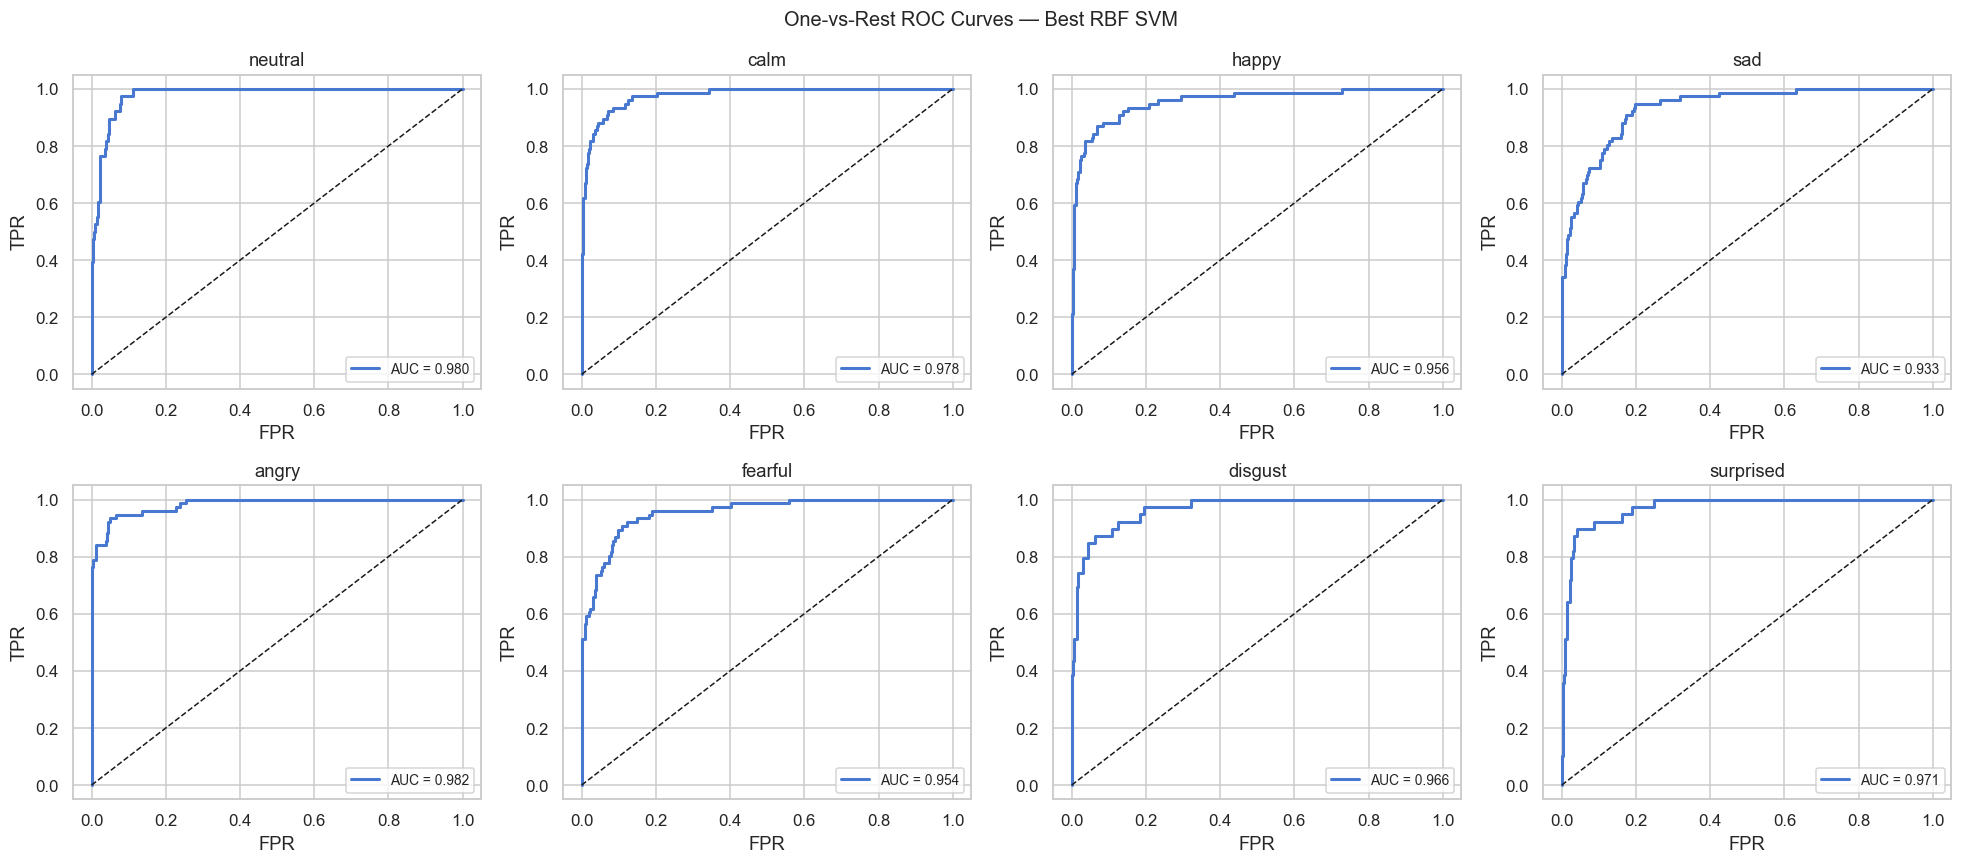

Macro-AUC (sklearn roc_curve) : 0.9650
Macro-AUC (minilearn)         : 0.9650

Per-class AUC:
  neutral     : 0.9798
  calm        : 0.9779
  happy       : 0.9564
  sad         : 0.9327
  angry       : 0.9821
  fearful     : 0.9542
  disgust     : 0.9658
  surprised   : 0.9712


In [5]:
# Refit best RBF with probability=True so we can get per-class scores for ROC
best_params = grid_search.best_params_
rbf_prob = SVC(
    kernel='rbf', probability=True, decision_function_shape='ovr',
    C=best_params['C'], gamma=best_params['gamma']
)
rbf_prob.fit(X_train, y_train)
y_score = rbf_prob.predict_proba(X_test)   # (n_test, n_classes)

classes = np.unique(y_train)               # [1..8]

# ── Per-class OVR ROC curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
aucs = []

for i, (c, ax) in enumerate(zip(classes, axes.flatten())):
    y_bin   = (y_test == c).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_score[:, i])
    auc_val = auc(fpr, tpr)
    aucs.append(auc_val)

    ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(EMOTION_MAP[c])
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('One-vs-Rest ROC Curves — Best RBF SVM', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves_svm.png'), bbox_inches='tight')
plt.show()

# ── Macro-averaged AUC ───────────────────────────────────────────────────────
macro_auc_sklearn  = float(np.mean(aucs))
macro_auc_minilearn = roc_auc_score(y_test, y_score)

print(f'Macro-AUC (sklearn roc_curve) : {macro_auc_sklearn:.4f}')
print(f'Macro-AUC (minilearn)         : {macro_auc_minilearn:.4f}')
print()
print('Per-class AUC:')
for c, a in zip(classes, aucs):
    print(f'  {EMOTION_MAP[c]:<12}: {a:.4f}')

## 5. Discussion

*Address:*
- *Which kernel produces the best results on SER?*
- *How sensitive is the RBF SVM to the choice of C and gamma?*
- *Which emotions have the highest AUC?  Which have the lowest?*